# 02 Retrieval Benchmark

This notebook compares retrieval methods and selects the deployment candidate from a reproducible benchmark.

The benchmark uses the frozen testset in `reports/ragas_testset.json`. The primary testset is generated with RAGAS TestsetGenerator; fallback/cached status is recorded explicitly when keys or quota are unavailable.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import json
import pandas as pd
from IPython.display import Image, Markdown, display

## 1. Build / Load Evaluation Testset

The frozen testset keeps retrieval comparisons reproducible. The table below shows whether the current artifact came from RAGAS or fallback data.

In [2]:
from src.evaluation.config import RAGAS_TESTSET_JSON, RAGAS_TESTSET_MD
from src.evaluation.testset import ensure_testset

testset = ensure_testset()
testset_meta = json.loads(RAGAS_TESTSET_JSON.read_text(encoding="utf-8"))
summary = {
    "questions": len(testset),
    "generated_with_ragas": testset_meta.get("generated_with_ragas"),
    "candidate_target": testset_meta.get("candidate_target"),
}
pd.DataFrame([summary])

,questions,generated_with_ragas,candidate_target
0,30,True,40


In [3]:
pd.DataFrame(testset)[["id", "topic", "source", "question"]].head(12)

,id,topic,source,question
0,ragas_001,single_hop_specific_query_synthesizer,ragas_testset_generator,Theo quy định tại CHƯƠNG VI thì khi xí nghiệp ...
1,ragas_002,single_hop_specific_query_synthesizer,ragas_testset_generator,Quy trình giải thể Xí nghiệp liên doanh được q...
2,ragas_003,single_hop_specific_query_synthesizer,ragas_testset_generator,Khi nào thì hội đồng quản trị của xí nghiệp li...
3,ragas_004,single_hop_specific_query_synthesizer,ragas_testset_generator,CHƯƠNG VI nói về cái gì vậy ạ?
4,ragas_005,single_hop_specific_query_synthesizer,ragas_testset_generator,anh oi cho hoi cai Nghị định số 103/1999/NĐ-CP...
5,ragas_006,single_hop_specific_query_synthesizer,ragas_testset_generator,Theo Nghị định số 103/1999/NĐ-CP của Chính phủ...
6,ragas_007,single_hop_specific_query_synthesizer,ragas_testset_generator,Nghị định số 103/1999/NĐ-CP quy định gì về việ...
7,ragas_008,single_hop_specific_query_synthesizer,ragas_testset_generator,Khi các bên lập phương án dựa trên hướng phát ...
8,ragas_009,single_hop_specific_query_synthesizer,ragas_testset_generator,UBND TỈNH LÂM ĐỒNG đã đánh giá như thế nào về ...
9,ragas_010,single_hop_specific_query_synthesizer,ragas_testset_generator,"Theo chỉ thị của UBND tỉnh Lâm Đồng, tình hình..."


## 2. Run Retrieval Benchmark

Compared methods: `bm25`, `vector`, `hybrid`, `hybrid_rrf`, and `hybrid_rrf_mmr`.

The selection score is fixed:

`0.30 * MRR + 0.25 * nDCG@5 + 0.25 * Context Precision + 0.20 * Context Recall`

Retrieval Context Precision/Recall is computed through `ragas.evaluate()` with RAGAS non-LLM context metrics so the full frozen testset can run reliably.

In [4]:
from src.evaluation.retrieval_benchmark import run_benchmark

retrieval_report = run_benchmark()
print("selected:", retrieval_report["selected_method"])
print("ragas backend:", retrieval_report["ragas_backend"])
print("benchmark chunks:", retrieval_report["num_chunks"])

C:\Users\Acer Nitro\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


selected: hybrid
ragas backend: ragas_evaluate_non_llm
benchmark chunks: 3500


In [5]:
retrieval_df = pd.DataFrame(retrieval_report["summary"]).sort_values("selection_score", ascending=False)
retrieval_df

,method,recall@5,mrr,ndcg@5,term_context_precision,term_context_recall,citation_coverage,ragas_context_precision,ragas_context_recall,selection_score
2,hybrid,1.0,1.0,0.958729,0.569532,0.887560,1.0,0.030556,0.100000,0.567321
3,hybrid_rrf,1.0,1.0,0.940614,0.552570,0.873842,1.0,0.033333,0.100000,0.563487
1,vector,1.0,1.0,0.931884,0.473102,0.787708,1.0,0.050000,0.066667,0.558804
4,hybrid_rrf_mmr,1.0,1.0,0.946929,0.516097,0.859915,1.0,0.027778,0.066667,0.557010
0,bm25,1.0,1.0,0.976453,0.588803,0.884928,1.0,0.008333,0.033333,0.552863


## 3. Visual Comparison

These figures are the main portfolio evidence: which method performs better, which metrics explain the difference, and which questions are difficult.

### retrieval_selection_score.png

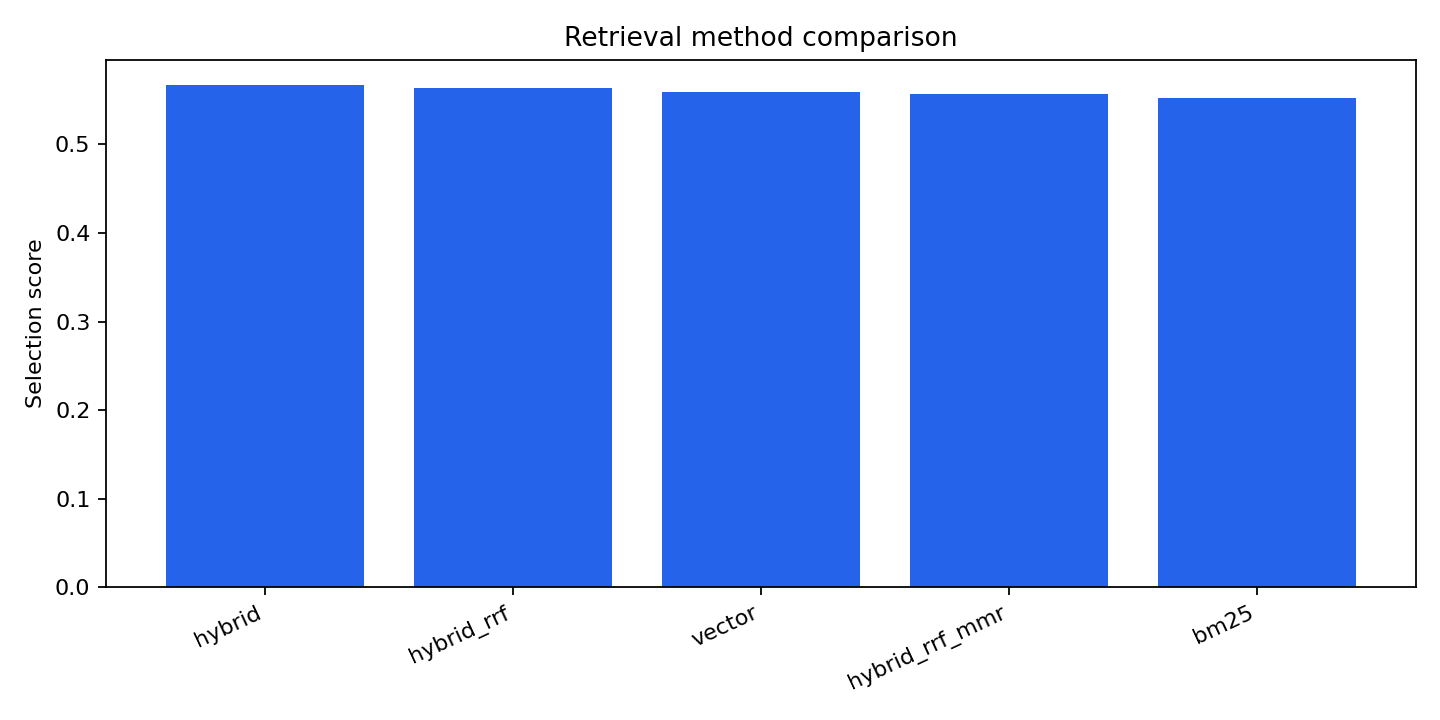

### retrieval_metric_comparison.png

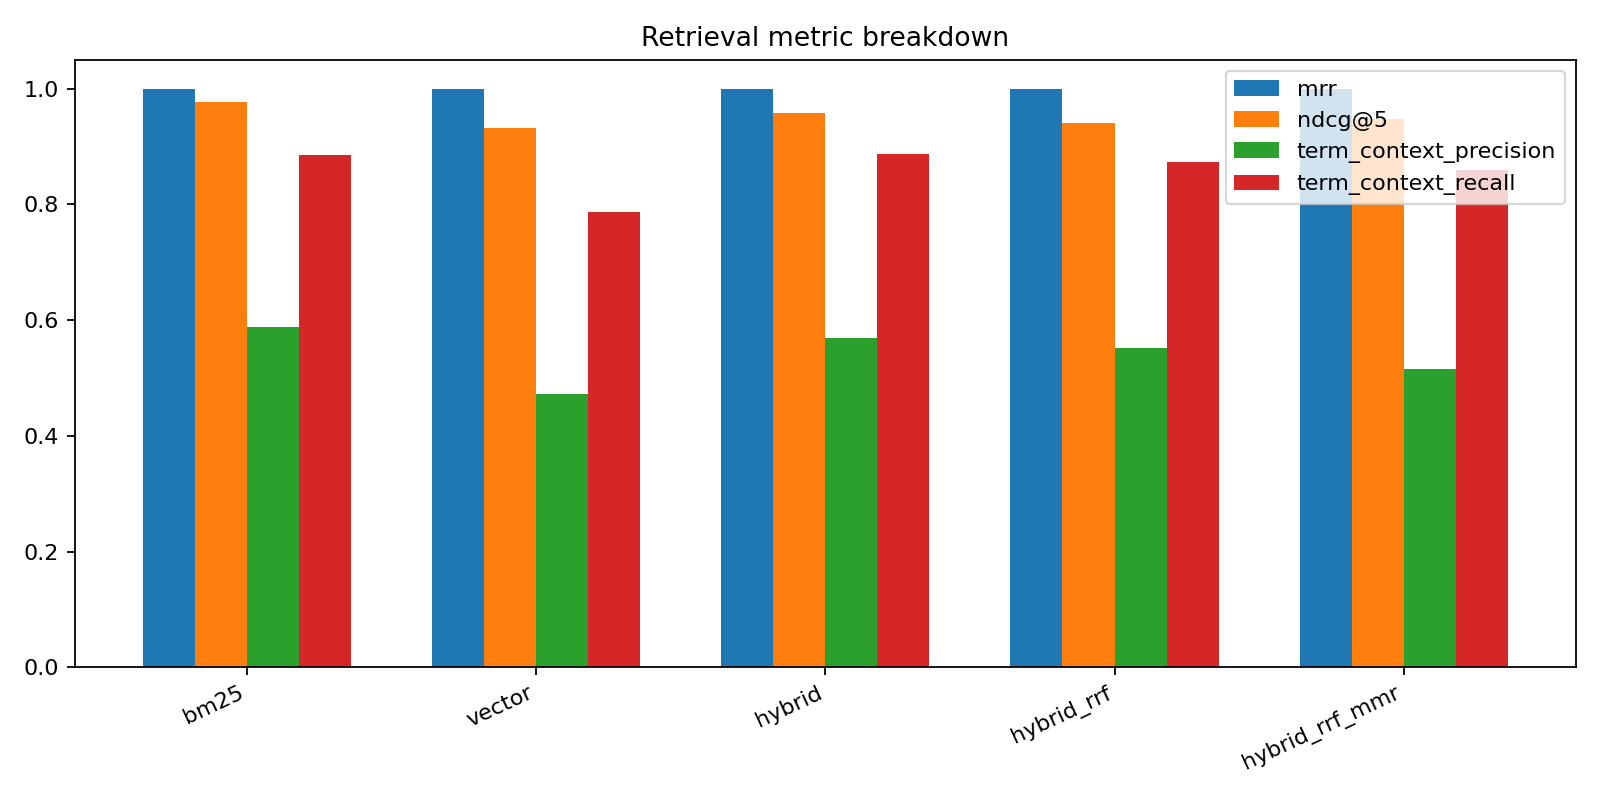

### retrieval_query_heatmap.png

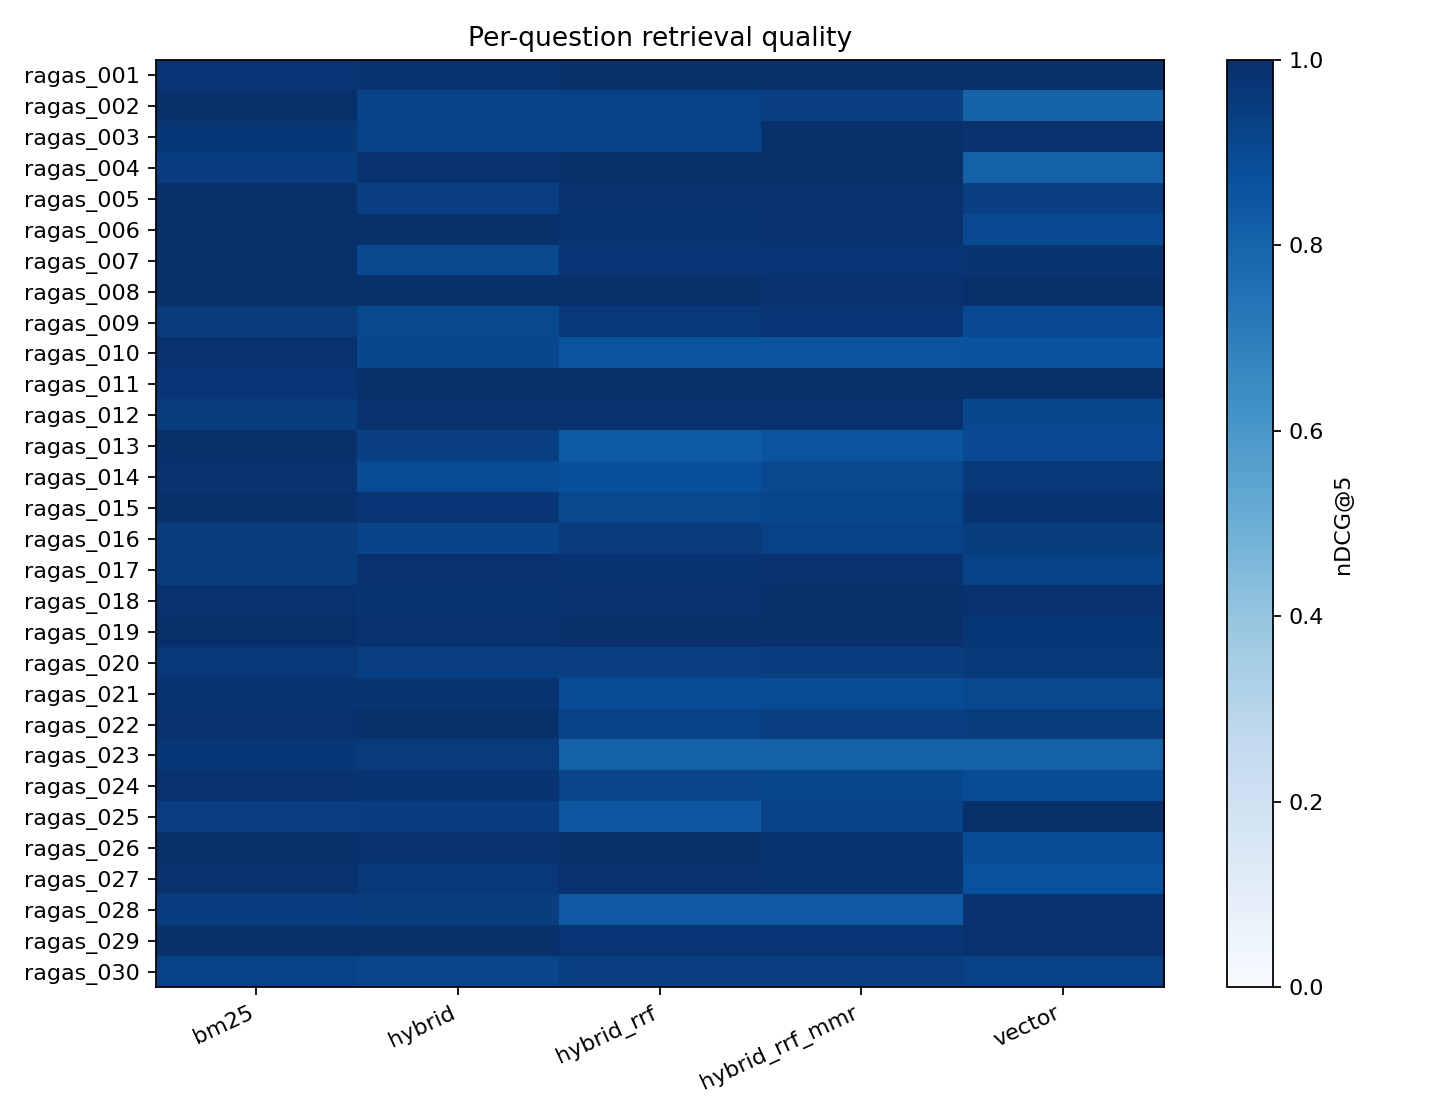

In [6]:
from src.evaluation.config import FIGURES_DIR

for name in ["retrieval_selection_score.png", "retrieval_metric_comparison.png", "retrieval_query_heatmap.png"]:
    display(Markdown(f"### {name}"))
    display(Image(filename=str(FIGURES_DIR / name)))

## 4. Per-question Diagnostics

Use this table to inspect failure cases instead of reading only aggregate scores.

In [7]:
details = pd.DataFrame(retrieval_report["details"])
cols = ["question_id", "method", "mrr", "ndcg@5", "term_context_precision", "term_context_recall", "top_title"]
details[cols].sort_values(["question_id", "ndcg@5"], ascending=[True, False]).head(30)

,question_id,method,mrr,ndcg@5,term_context_precision,term_context_recall,top_title
120,ragas_001,hybrid_rrf_mmr,1.0,1.000000,0.703704,1.000000,Hướng dẫn thi hành Quy chế lao động đối với cá...
90,ragas_001,hybrid_rrf,1.0,0.996166,0.725926,1.000000,Hướng dẫn thi hành Quy chế lao động đối với cá...
30,ragas_001,vector,1.0,0.993830,0.674074,1.000000,Hướng dẫn thi hành Quy chế lao động đối với cá...
60,ragas_001,hybrid,1.0,0.980418,0.725926,1.000000,Hướng dẫn thi hành Quy chế lao động đối với cá...
0,ragas_001,bm25,1.0,0.973054,0.692593,1.000000,Hướng dẫn thi hành Quy chế lao động đối với cá...
1,ragas_002,bm25,1.0,0.992881,0.560656,0.885246,Về việc chấn chỉnh và tổ chức lại sản xuất và ...
121,ragas_002,hybrid_rrf_mmr,1.0,0.934126,0.557377,0.950820,Về việc chấn chỉnh và tổ chức lại sản xuất và ...
91,ragas_002,hybrid_rrf,1.0,0.928597,0.613115,0.934426,Về việc chấn chỉnh và tổ chức lại sản xuất và ...
61,ragas_002,hybrid,1.0,0.924992,0.632787,0.950820,Về việc chấn chỉnh và tổ chức lại sản xuất và ...
31,ragas_002,vector,1.0,0.804577,0.406557,0.819672,Ban hành Điều lệ xí nghiệp liên doanh (còn gọi...


## 5. Decision

The selected method comes from the benchmark, not a hardcoded choice. If the testset or metric outputs change, this conclusion changes with the report.

In [8]:
selected = retrieval_report["selected_method"]
score = retrieval_df.iloc[0]["selection_score"]
Markdown(f"**Selected retrieval method:** `{selected}` with selection score `{score:.3f}`.")

**Selected retrieval method:** `hybrid` with selection score `0.567`.